In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from numerical_approximation.chemotaxis import (
    ArcParams,
    ArcPhiParams,
    Endpoint,
    ExternalBC,
    InternalNode,
    arc_mass,
    plot_density_snapshots,
    step_network,
    validate_network,
)

In [2]:
n_edges = 3
n_nodes = 4 # Not coupling these for now

kappa = np.ones((n_edges,n_edges))
np.fill_diagonal(kappa, 0)

# Each edge has its own parameter set
D = [1 for _ in range(n_edges)]
a = [1 for _ in range(n_edges)]
b = [0.1 for _ in range(n_edges)]

Outer boundary conditions for $\phi$ to mimic the presence of food at the left and lower ends:
$$
\partial_x \phi_1(0, t) = -1;\; \partial_x \phi_2(L_2, t) = 1
$$

In [3]:
LEFT_TRUNK, RIGHT_TRUNK, STEM = 0, 1, 2

L = 1.0                # length of every arc
lam = math.sqrt(0.33)  # transport speed
chi = 1.0               # chemotactic sensitivity
M = 30                  # interior grid points per arc
h = L / (M + 1)
k = h / (2 * lam)  # CFL: h = 2*k*lam

arc_params = {i: ArcParams(lam=lam, h=h, k=k, chi=chi) for i in range(n_edges)}
phi_arc_params = {i: ArcPhiParams(D=D[i], a=a[i], b=b[i], h=h, k=k, M=M) for i in range(n_edges)}

external_bcs = [
    ExternalBC(Endpoint(LEFT_TRUNK, "left"), kind="flux", phibar=-1.0),   # Eq. (41): phi_x_1(0,t) = -1
    ExternalBC(Endpoint(RIGHT_TRUNK, "right"), kind="flux", phibar=1.0),  # Eq. (41): phi_x_2(L_2,t) = 1
    ExternalBC(Endpoint(STEM, "right"), kind="robin1"),                   # Eq. (42): food-free outer end
]

# The internal node joins one endpoint per arc. kappa (phi coupling) is
# edge-indexed (defined above); xi (u/v coupling) sends 1/3 of each arc's
# outgoing characteristic into every arc at the node.
node_endpoints = [Endpoint(LEFT_TRUNK, "right"), Endpoint(RIGHT_TRUNK, "left"), Endpoint(STEM, "left")]
kappa_dict = {(i, j): kappa[i, j] for i in range(n_edges) for j in range(n_edges) if i != j}
xi = {(i, j): 1 / 3 for i, _ in node_endpoints for j, _ in node_endpoints}
internal_node = InternalNode(endpoints=node_endpoints, kappa=kappa_dict, xi=xi)

# u/v boundary kind at the external (non-node) arc ends
BC_TYPE = {
    (LEFT_TRUNK, "left"): "neumann",
    (RIGHT_TRUNK, "right"): "neumann",
    (STEM, "right"): "neumann",
}

validate_network(arc_params, BC_TYPE, external_bcs, [internal_node])

In [4]:
T = 20 # total simulated time
n_time_steps = round(T / k) + 1

u_minus = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}
u_plus = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}
phi = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}

# Plasmodium spread ~ U[0.25, 0.35] on each arc; phi(x,0) = 0; v(x,0) = 0
# (i.e. u_minus = u_plus = u/2, at rest) to mimic plasmodium already
# occupying the whole network.
rng = np.random.default_rng()
for i in range(n_edges):
    u0 = rng.uniform(0.25, 0.35, size=M + 2)
    u_minus[i][0, :] = u0 / 2
    u_plus[i][0, :] = u0 / 2

record_every = 5
t_history = []
mass_history = {i: [] for i in range(n_edges)}

for n in range(n_time_steps - 1):
    if n % record_every == 0:
        t_history.append(n * k)
        for i in range(n_edges):
            mass_history[i].append(arc_mass(u_minus[i][n], u_plus[i][n], h))

    step_network(
        u_minus, u_plus, phi, n,
        arc_params, phi_arc_params, BC_TYPE,
        external_bcs, [internal_node],
    )

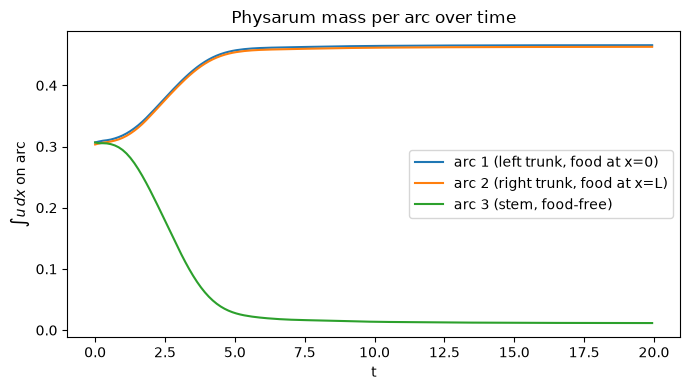

In [5]:
arc_labels = {
    LEFT_TRUNK: "arc 1 (left trunk, food at x=0)",
    RIGHT_TRUNK: "arc 2 (right trunk, food at x=L)",
    STEM: "arc 3 (stem, food-free)",
}

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(n_edges):
    ax.plot(t_history, mass_history[i], label=arc_labels[i])
ax.set_xlabel("t")
ax.set_ylabel(r"$\int u\,dx$ on arc")
ax.set_title("Physarum mass per arc over time")
ax.legend()
plt.tight_layout()
plt.show()

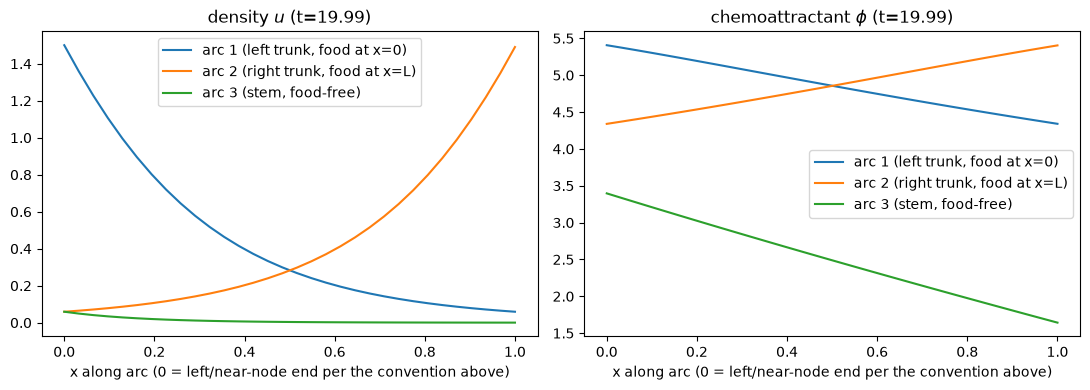

In [6]:
x = np.linspace(0, L, M + 2)

fig, (ax_u, ax_phi) = plt.subplots(1, 2, figsize=(11, 4))
for i in range(n_edges):
    u_final = u_minus[i][-1] + u_plus[i][-1]
    ax_u.plot(x, u_final, label=arc_labels[i])
    ax_phi.plot(x, phi[i][-1], label=arc_labels[i])

ax_u.set_title(f"density $u$ (t={(n_time_steps - 1) * k:.2f})")
ax_phi.set_title(r"chemoattractant $\phi$" + f" (t={(n_time_steps - 1) * k:.2f})")
for axx in (ax_u, ax_phi):
    axx.set_xlabel("x along arc (0 = left/near-node end per the convention above)")
    axx.legend()
plt.tight_layout()
plt.show()

## Density on the graph itself

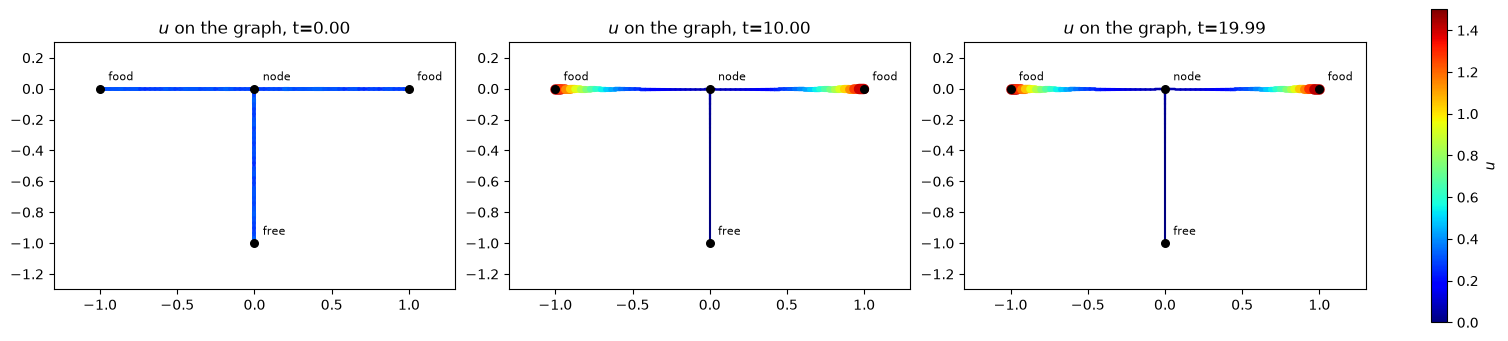

In [7]:
# Positions keyed by internal-node index (into [internal_node]) or by
# external end (arc, side). Each arc is drawn from its j=0 end to its j=M+1 end.
NODE_POS = {
    0: (0.0, 0.0),
    (LEFT_TRUNK, "left"): (-1.0, 0.0),
    (RIGHT_TRUNK, "right"): (1.0, 0.0),
    (STEM, "right"): (0.0, -1.0),
}
NODE_LABELS = {
    0: "node",
    (LEFT_TRUNK, "left"): "food",
    (RIGHT_TRUNK, "right"): "food",
    (STEM, "right"): "free",
}

snapshot_indices = sorted({0, (n_time_steps - 1) // 2, n_time_steps - 1})

plot_density_snapshots(
    NODE_POS, [internal_node], external_bcs, u_minus, u_plus, snapshot_indices, k,
    node_labels=NODE_LABELS,
)
plt.show()